# ¡Hola Cesar!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>


# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

### Comentario General Iteración #1
<div class="alert alert-block alert-success">

Cesar, quería dejarte aquí una apreciación general de tu proyecto para que a partir de allí nos vayamos punto por punto. 

Primero que nada, espero qu este camino en el mundo de los datos esté siendo muy interesante y lleno de aprendizajes significativos. Espero que lo disfrutes y puedas hacerte muchas preguntas que te lleven a analizar y ver los datos como si fueran historias, porque al final, ese es nuestro objetivo!

Respecto a tu trabajo en esta primera iteración, felicitarte porque has mostrado tus conocimientos de la mejor forma, utilizando los metodos correctamente, realizando filtros de forma sencilla y trabajando con los diferentes datasets para llegar a las respuestas de negocio que se buscaban en este proyecto. 

Sigue aprendiendo bastante en este camino, excelente trabajo!
</div>

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:

# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv') 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB



#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes
.


In [3]:
# mostrar las primeras 5 filas
df.head()


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Buen trabajo con la importación de las librerías y datasets requeridos, al igual que con los métodos para la exploración inicial de los datos.

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfacción`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .edad está almacenada como float64, aunque representa una variable discreta (años de edad), por lo que podría convertirse a int64 si se confirma que no existen valores decimales. Las demás variables tienen un tipo de dato consistente con la información que representan.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional. La columna `id_cliente` funciona únicamente como identificador único y no será utilizada en los análisis estadísticos o de correlación, ya que no aporta información analítica sobre el comportamiento de los clientes.

In [4]:

# Corregir el tipo de dato
df.dtypes


id_cliente                    object
edad                         float64
nivel_ingreso                float64
visitas_mes                    int64
compras_mes                    int64
gasto_publicidad_dirigida    float64
satisfaccion                 float64
miembro_premium                int64
abandono                       int64
tipo_dispositivo              object
region                        object
ingreso_anual                float64
dtype: object

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` — Los clientes tienen edades entre 18 y 75 años, con una media de 38.3 años. La distribución parece razonable y no se observan valores fuera del rango esperado.
- `nivel_ingreso` — El ingreso anual estimado presenta una media de 30,019.70 y un rango entre 8,000 y 74,790.84, lo que indica una amplia diversidad económica entre los clientes.
- `visitas_mes` — Los clientes realizan en promedio 10 visitas mensuales, con valores entre 1 y 25, reflejando distintos niveles de interacción con la plataforma
- `compras_mes` — El promedio es de 1.21 compras por mes, con un máximo de 8 compras. Además, el primer cuartil es 0, lo que indica que al menos el 25 % de los clientes no realizó compras durante el mes analizado
- `gasto_publicidad_dirigida` — El gasto promedio en publicidad es de 20.15, con valores entre 0 y 75.51. Existen clientes que no recibieron inversión publicitaria.
- `satisfaccion` — La satisfacción se encuentra dentro de la escala esperada de 1 a 5, con una media de 3.60, lo que sugiere una percepción general moderadamente positiva.
- `miembro_premium` — La media de 0.139 indica que aproximadamente el 13.9 % de los clientes cuenta con una suscripción premium
- `abandono` — La media de 0.151 muestra que cerca del 15.1 % de los clientes abandonó la plataforma durante el período analizado.
- `ingreso_anual` — Es la variable objetivo del análisis. Presenta una media de 36.59 y un rango entre 0 y 244.69. Además, el primer cuartil es 0, lo que indica que al menos el 25 % de los clientes no generó ingresos para la empresa durante el período analizado, aspecto que deberá considerarse al interpretar las correlaciones.

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
print("miembro_premium:", df["miembro_premium"].unique())
print("abandono:", df["abandono"].unique())

miembro_premium: [0 1]
abandono: [0 1]


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — La variable contiene únicamente los valores 0 y 1, por lo que está correctamente codificada como una variable binaria y no requiere transformaciones adicionales. 
- `abandono` — La variable también presenta únicamente los valores 0 y 1, indicando que la codificación es consistente y adecuada para el análisis.

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']

for columna in columnas_categoricas:
    print(f"{columna}: {df[columna].nunique()} valores únicos")

id_cliente: 15000 valores únicos
tipo_dispositivo: 3 valores únicos
region: 4 valores únicos


In [9]:
# Explorar variables categóricas y cómo se distribuyen

columnas_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']

for columna in columnas_categoricas:
    print(f"\nDistribución de {columna}:")
    print(df[columna].value_counts())


Distribución de id_cliente:
CL-111254    1
CL-102875    1
CL-102505    1
CL-108881    1
CL-110471    1
            ..
CL-106786    1
CL-104599    1
CL-113918    1
CL-110962    1
CL-105282    1
Name: id_cliente, Length: 15000, dtype: int64

Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución de region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

**Diagnóstico inicial de variables categóricas**
Se identificaron tres variables categóricas en el conjunto de datos:


- `tipo_dispositivo` — Presenta 3 categorías (móvil, escritorio y tablet). Se observa un predominio del uso de móvil (9,818 clientes), seguido por escritorio (3,720) y tablet (1,462), lo que indica que la mayoría de los clientes interactúa con la plataforma desde dispositivos móviles.
- `id_cliente` — Contiene 15,000 valores únicos, por lo que corresponde a un identificador único para cada cliente. No aporta información para el análisis estadístico o correlacional y se utilizará únicamente como referencia de identificación.
- `region` — Contiene 4 categorías (norte, oeste, sur y este). La distribución es relativamente equilibrada, aunque la región norte concentra el mayor número de clientes (4,395), mientras que este presenta la menor cantidad (3,069).

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Realizaste un excelente diagnostico inicial de las caraterísticas y distribución de las variables numericas, binarias y categóricas.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

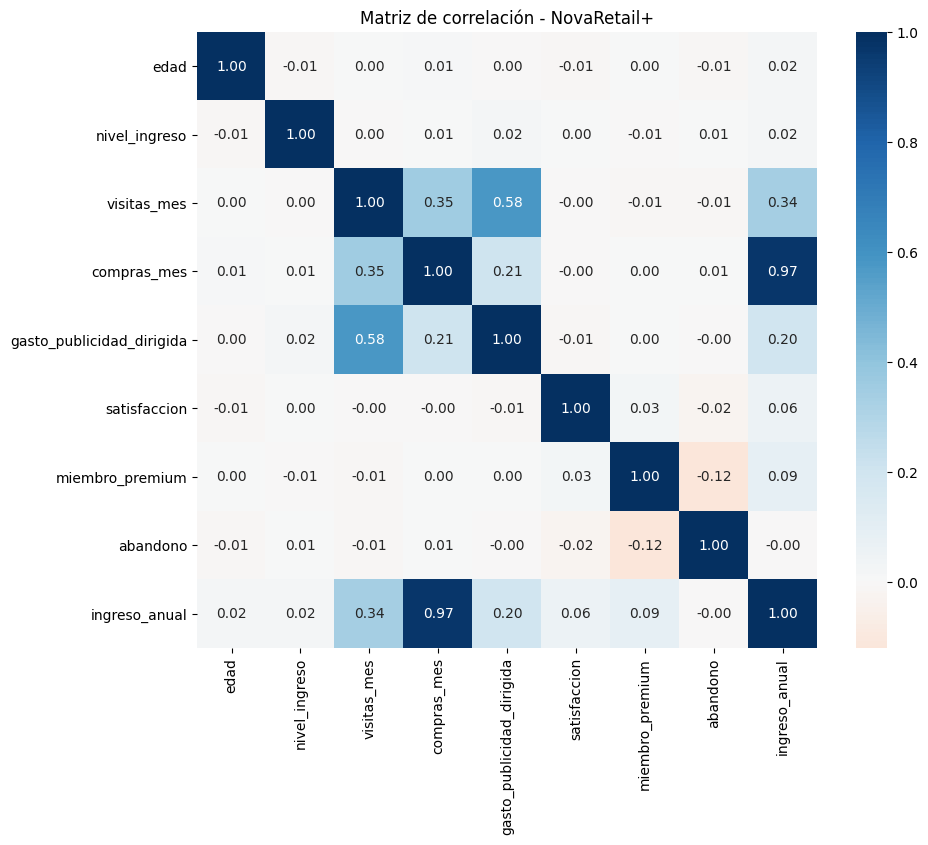

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
df_numericas = df.select_dtypes(include='number')

corr = df_numericas.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu',
    center=0,
    fmt='.2f'
)

plt.title('Matriz de correlación - NovaRetail+')

plt.show()



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves

Observaciones generales (Heatmap)  
- Se observa ... que la mayoría de las variables presentan correlaciones débiles o cercanas a cero, lo que indica que no existe una relación lineal importante entre la mayoría de los pares de variables. Sin embargo, destacan algunas asociaciones positivas de magnitud moderada y una relación muy fuerte entre determinadas variables de comportamiento e ingreso_anual.


Observaciones respecto a `ingreso_anual`  
- Presenta... a las `compras_mes` la correlación positiva más fuerte con ingreso_anual (r = 0.97), lo que sugiere una asociación lineal muy alta entre la cantidad de compras y el ingreso generado por el cliente.
- `visitas_mes` muestra una correlación positiva moderada con ingreso_anual (r = 0.34), indicando que los clientes que visitan con mayor frecuencia la plataforma tienden a generar mayores ingresos, aunque la relación no es tan fuerte como la observada con las compras.
- `gasto_publicidad_dirigida` presenta una correlación positiva débil con ingreso_anual (r = 0.20), lo que sugiere una asociación limitada entre la inversión publicitaria y el ingreso generado.
- `satisfaccion` (r = 0.06), miembro_premium (r = 0.09), edad (r = 0.02)
- `nivel_ingreso` (r = 0.02) y abandono (≈ 0.00) muestran correlaciones muy bajas con ingreso_anual, por lo que no evidencian una relación lineal relevante en este análisis.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
Decido incluirla ya que con base en el heatmap, sí es recomendable incluir un scatterplot general, ya que permite confirmar visualmente la relación observada entre las variables con mayor correlación y detectar posibles patrones no lineales, agrupamientos o valores atípicos.
  - Genera el gráfico.
  - **Describe brevemente qué patrones o tendencias observas.**
    El gráfico confirma que `compras_mes` presenta una relación positiva muy fuerte con `ingreso_anual`, observándose una clara tendencia ascendente entre ambas variables.
    Entre `visitas_mes` e `ingreso_anual` también se aprecia una tendencia positiva, aunque con una mayor dispersión de los datos, consistente con la correlación moderada observada en el heatmap
    La relación entre `gasto_publicidad_dirigida` e `ingreso_anual` es más débil, ya que los puntos se encuentran más dispersos y no siguen una tendencia lineal tan marcada.

- **Si decides no incluirlo**:
  - Explica por qué. NA, YA QUE SI SE INCLUYO

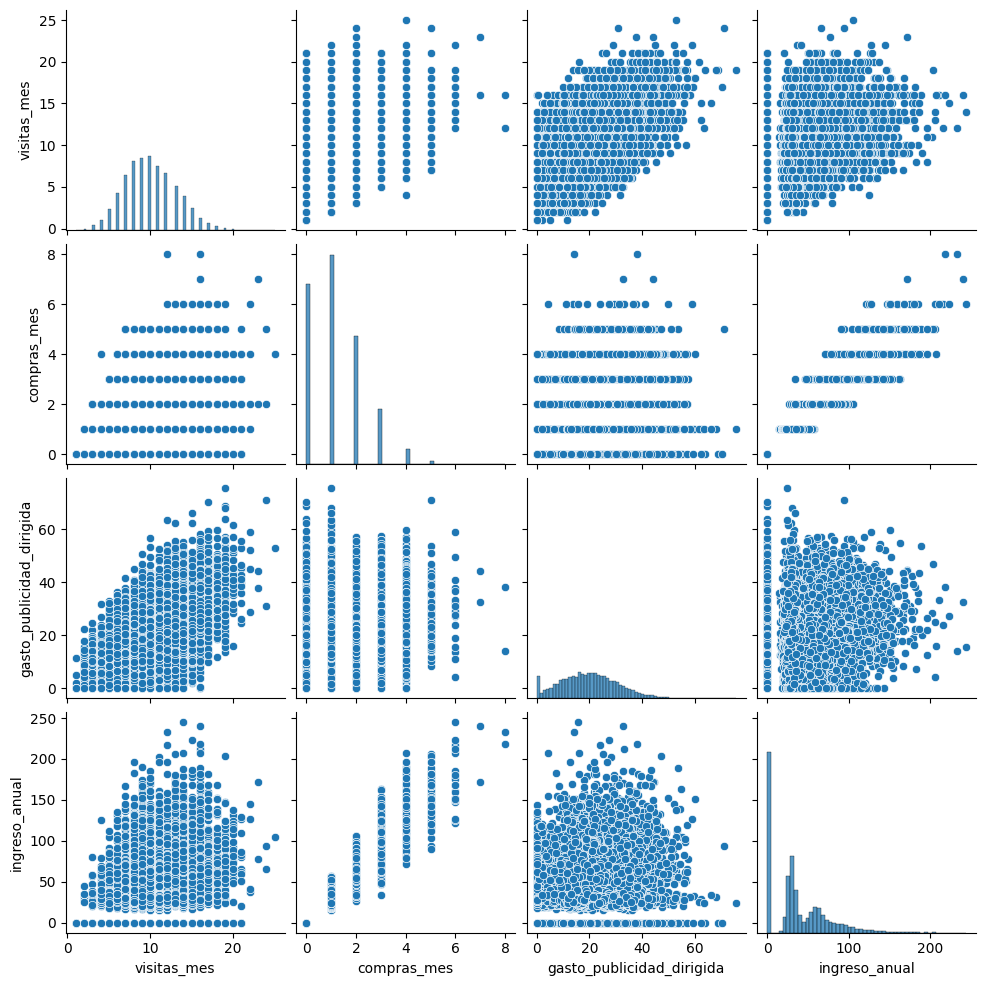

In [11]:
sns.pairplot(
    df[
        [
            'visitas_mes',
            'compras_mes',
            'gasto_publicidad_dirigida',
            'ingreso_anual'
        ]
    ]
)

plt.show()

### Scatterplot para pares clave

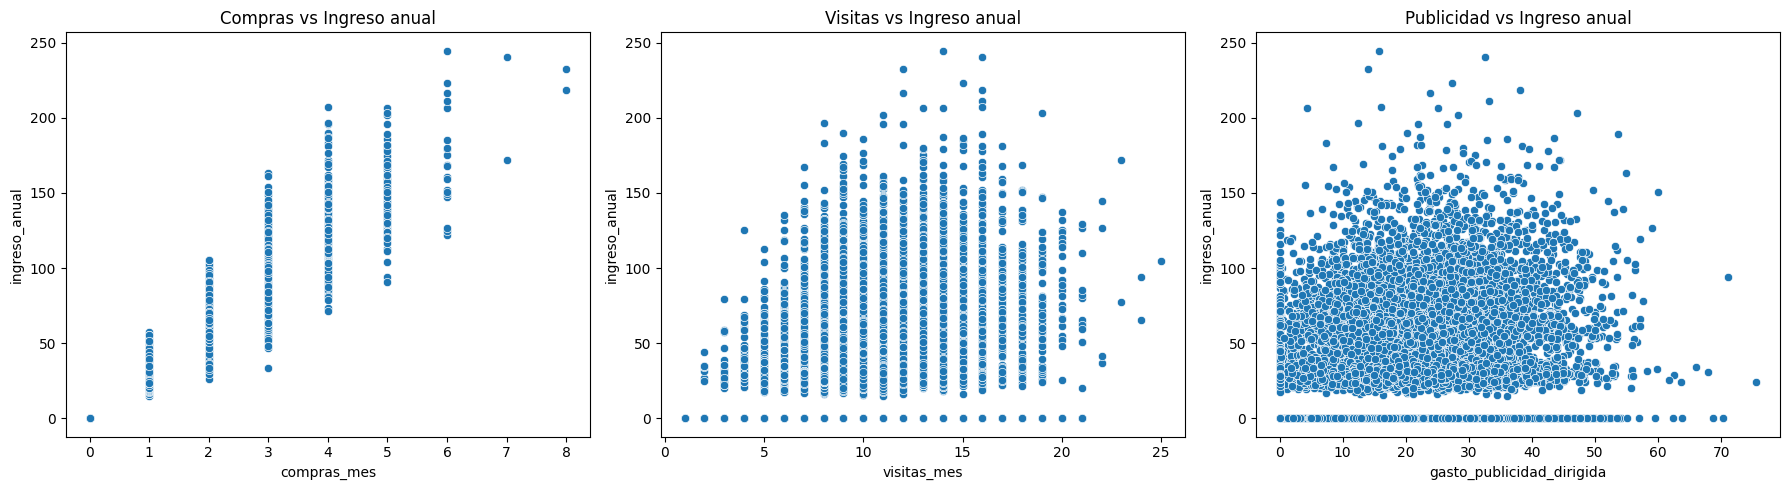

In [12]:

# Visualizar pares de variables con relaciones moderadas o fuertes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Compras vs ingreso anual
sns.scatterplot(
    data=df,
    x='compras_mes',
    y='ingreso_anual',
    ax=axes[0]
)
axes[0].set_title('Compras vs Ingreso anual')

# Visitas vs ingreso anual
sns.scatterplot(
    data=df,
    x='visitas_mes',
    y='ingreso_anual',
    ax=axes[1]
)
axes[1].set_title('Visitas vs Ingreso anual')

# Publicidad vs ingreso anual
sns.scatterplot(
    data=df,
    x='gasto_publicidad_dirigida',
    y='ingreso_anual',
    ax=axes[2]
)
axes[2].set_title('Publicidad vs Ingreso anual')

plt.tight_layout()
plt.show()


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**var1 vs var2**
- `compras_mes` vs `ingreso_anual`    
- Dirección ...Positiva fuerte.
- Dispersión: Baja. Los puntos siguen una tendencia ascendente claramente definida.
- Outliers: Se observan algunos clientes con ingresos anuales muy altos, especialmente entre 6 y 8 compras mensuales, pero no alteran la tendencia general.
- Posible colinealidad: Sí. La relación es muy fuerte y coincide con la correlación de 0.97, lo que sugiere una alta asociación lineal entre ambas variables.

**var1 vs var3**
`visitas_mes` vs `ingreso_anual`  
- Dirección ...Positiva.
- Dispersión: Media. Aunque existe una tendencia ascendente, los puntos presentan una mayor variabilidad que en el gráfico anterior.
- Outliers: Se observan algunos clientes con ingresos elevados para determinados niveles de visitas, pero no predominan en la distribución.
- Posible colinealidad: No. La relación es moderada (r ≈ 0.34), por lo que no indica una colinealidad importante.
  
  **var3 vs var2**
  `Publicidad` vs `ingreso anual`
- Dirección: Positiva muy débil.
- Dispersión: Alta. Los puntos se encuentran ampliamente dispersos y no forman un patrón lineal claro.
- Outliers: Existen algunos clientes con ingresos elevados y distintos niveles de gasto publicitario, además de varios registros con ingreso anual igual a cero.
- Posible colinealidad: No. La correlación observada (r ≈ 0.20) es baja y la dispersión confirma que la relación lineal es limitada.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Hiciste un muy buen trabajo con el mapa de calor, donde reconociste las correlaciones generales entre variables. El analisis de pares clave también está muy correcto, la elección de `compras_mes` vs `ingreso_anual` y `visitas_mes` y `gasto_publicidad_dirigida` es muy valiosa, como mencionas sobre estas relaciones, vale la pena revisar para entender como pueden influir en publicidad, satisfacción y otros factores.  

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [13]:

# Calcular correlación entre variables relevantes
correlaciones = df[['compras_mes',
                    'visitas_mes',
                    'gasto_publicidad_dirigida',
                    'ingreso_anual']].corr(method='pearson')

print(correlaciones)

                           compras_mes  visitas_mes  \
compras_mes                   1.000000     0.353844   
visitas_mes                   0.353844     1.000000   
gasto_publicidad_dirigida     0.207528     0.578947   
ingreso_anual                 0.967149     0.337147   

                           gasto_publicidad_dirigida  ingreso_anual  
compras_mes                                 0.207528       0.967149  
visitas_mes                                 0.578947       0.337147  
gasto_publicidad_dirigida                   1.000000       0.197483  
ingreso_anual                               0.197483       1.000000  


In [14]:

# Calcular correlación entre variables relevantes
correlaciones['ingreso_anual'].sort_values(ascending=False)

ingreso_anual                1.000000
compras_mes                  0.967149
visitas_mes                  0.337147
gasto_publicidad_dirigida    0.197483
Name: ingreso_anual, dtype: float64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**var1 vs var2**
- `compras_mes` vs `ingreso_anual`

Correlación: 0.967

Dirección: Positiva.

Magnitud: Muy fuerte.

Interpretación: Existe una relación lineal muy fuerte; a mayor número de compras mensuales, mayor ingreso anual generado. Esta es la asociación más fuerte del análisis.- 

**var2 vs var3**

`visitas_mes` vs `gasto_publicidad_dirigida`

Correlación: 0.579

Dirección: Positiva.

Magnitud: Moderada.

Interpretación: Se observa una relación positiva moderada; los clientes que reciben mayor publicidad dirigida tienden a realizar más visitas. La correlación no es lo suficientemente alta como para indicar problemas de colinealidad.

**Posible colinealidad**
- No se observa una colinealidad fuerte entre las variables independientes analizadas. La correlación más alta entre ellas es 0.579 (visitas_mes y gasto_publicidad_dirigida), valor inferior al umbral comúnmente utilizado (≈0.80) para considerar colinealidad significativa.
  
- Aunque `compras_mes` e `ingreso_anual` tienen una correlación de 0.967, no se considera colinealidad, porque `ingreso_anual` es la variable objetivo (dependiente). 


### Punto-biserial

In [15]:

# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr
corr_premium, p_premium = pointbiserialr(
    df['miembro_premium'],
    df['ingreso_anual']
)
corr_abandono, p_abandono = pointbiserialr(
    df['abandono'],
    df['ingreso_anual']
)

print(f"Miembro premium vs ingreso_anual")
print(f"Coeficiente: {corr_premium:.3f}")
print(f"p-value: {p_premium:.4f}")

print("\nAbandono vs ingreso_anual")
print(f"Coeficiente: {corr_abandono:.3f}")
print(f"p-value: {p_abandono:.4f}")



Miembro premium vs ingreso_anual
Coeficiente: 0.093
p-value: 0.0000

Abandono vs ingreso_anual
Coeficiente: -0.003
p-value: 0.7295


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**var1 vs var2**
`Miembro_premium` vs `ingreso_anual`
- Relación ... positiva y muy débil. Aunque el coeficiente es bajo,
- el p-value indica que la relación es estadísticamente significativa.
- Esto sugiere que quienes tienen mayores ingresos tienen una ligera mayor probabilidad de ser miembros premium, pero el efecto es pequeño.

**var2 vs var3**
 `Abandono` vs `ingreso_anual`
- Relación ... negativa y prácticamente inexistente
- El coeficiente es muy cercano a cero (-0.003) y el p-value indica que la relación no es estadísticamente significativa.
- Esto sugiere que el ingreso anual no tiene una relación clara con el abandono de clientes y no parece ser un factor relevante para explicar esta variable.

### V de Cramér

In [16]:
# Función para calcular V de Cramér


In [17]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(df, col1, col2):
    tabla = pd.crosstab(df[col1], df[col2])
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.to_numpy().sum()
    r, k = tabla.shape

    return np.sqrt(chi2 / (n * (min(r, k) - 1)))
    
# Aplicar V de Cramér en variables relevantes

print("tipo_dispositivo vs region")
print(f"V de Cramér: {cramers_v(df, 'tipo_dispositivo', 'region'):.3f}")

print("\nmiembro_premium vs abandono")
print(f"V de Cramér: {cramers_v(df, 'miembro_premium', 'abandono'):.3f}")




tipo_dispositivo vs region
V de Cramér: 0.012

miembro_premium vs abandono
V de Cramér: 0.120


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

**Observaciones V de Cramér**

`tipo_dispositivo` vs `region` 
- V de Cramér: 0.012
Se observa una asociación prácticamente nula entre el tipo de dispositivo utilizado y la región del cliente. Esto indica que la distribución de los dispositivos es muy similar entre las diferentes regiones y no existe una relación significativa entre estas variables.

`miembro_premium` vs `abandono`
- V de Cramér: 0.120
Se observa una asociación débil entre ser miembro premium y el abandono de la plataforma. Aunque existe cierta relación entre ambas variables, su magnitud es baja, por lo que la membresía premium, por sí sola, no parece explicar de manera importante el comportamiento de abandono.

**Conclusión**: 
En ambos casos los coeficientes de V de Cramér son bajos (menores a 0.20), lo que indica que las asociaciones entre las variables categóricas analizadas son débiles o prácticamente inexistentes. No se identifican relaciones categóricas fuertes que puedan considerarse determinantes en el comportamiento de los clientes.




<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Muy buen calculo de los diferentes coeficientes para entender la asociacion entre categorías. 


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — 

**Evidencia visual:**
El scatterplot de `compras_mes` vs `ingreso_anual` muestra una tendencia ascendente clara. A medida que aumenta el número de compras mensuales, también aumenta el ingreso anual generado por cliente. La dispersión de los puntos es baja en comparación con otras variables analizadas, lo que indica una relación lineal consistente. Se observan algunos clientes con ingresos elevados asociados a mayores niveles de compras, pero no representan una alteración significativa del patrón general.

**Evidencia numérica:** 
La correlación de Pearson entre `compras_mes` e `ingreso_anual` es: r = 0.967.
Esto representa una relación positiva muy fuerte entre ambas variables. Además, `compras_mes` presenta la mayor correlación con `ingreso_anual` frente al resto de variables evaluadas:
`compras_mes` → `ingreso_anual`: 0.967
`visitas_mes` → `ingreso_anual`: 0.337
`gasto_publicidad_dirigida` → `ingreso_anual`: 0.197

**Interpretación** 
Los clientes que realizan más compras mensuales tienden a generar mayores ingresos anuales para NovaRetail+. El comportamiento de compra aparece como el indicador más relacionado con el valor económico generado por cada cliente dentro del período analizado.

**No podemos afirmar** 
No podemos afirmar que aumentar directamente el número de compras causará automáticamente un incremento del ingreso anual, ya que el análisis identifica una asociación estadística, pero no demuestra una relación causal. También pueden existir otros factores no incluidos en el análisis que influyan en esta relación, como promociones, categorías compradas o hábitos específicos de consumo.


**Implicación de negocio** 
NovaRetail+ podría priorizar estrategias enfocadas en aumentar la frecuencia de compra, como programas de fidelización, recomendaciones personalizadas, incentivos para clientes recurrentes y campañas de reactivación. La métrica de compras mensuales puede utilizarse como un indicador clave para identificar clientes con mayor potencial de generación de ingresos.


### Hallazgo 2 — 

**Evidencia visual:** 
El scatterplot de `visitas_mes` vs `ingreso_anual` muestra una tendencia positiva: los clientes con mayor número de visitas tienden a generar mayores ingresos. Sin embargo, los puntos presentan una dispersión más amplia que en la relación entre `compras_mes` e `ingreso_anual`, indicando que visitar más la plataforma no siempre se traduce directamente en mayores ingresos.

**Evidencia numérica:**
La correlación de Pearson entre `visitas_mes` e `ingreso_anual` es: r = 0.337
Esto representa una relación positiva moderada. Aunque la asociación es menor que la observada con `compras_mes`, `visitas_mes` ocupa el segundo lugar entre las variables de comportamiento analizadas respecto al ingreso anual.
Adicionalmente, se observa una relación moderada entre: `visitas_mes` vs `gasto_publicidad_dirigida`: r = 0.579
Lo que indica que los clientes que reciben mayor inversión publicitaria tienden a presentar más visitas a la plataforma.


**Interpretación** 
La frecuencia de interacción con NovaRetail+ está relacionada con una mayor generación de ingresos, pero la relación es menos directa que la observada con las compras. Las visitas pueden representar una etapa previa del proceso de conversión, donde algunos clientes exploran la plataforma, pero no necesariamente terminan realizando compras.

**No podemos afirmar** 
No podemos afirmar que incrementar las visitas de los clientes provocará automáticamente mayores ingresos. El análisis solamente muestra una asociación entre ambas variables y no determina si las visitas generan compras o si los clientes con mayor intención de compra son quienes naturalmente visitan más la plataforma.

**Implicación de negocio** 
NovaRetail+ podría utilizar las visitas mensuales como una señal temprana de interés del cliente. Estrategias como recomendaciones personalizadas, recordatorios de productos vistos, optimización de la experiencia digital y campañas dirigidas podrían ayudar a convertir mayor interacción en compras efectivas.


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente trabajo. Los hallazgos se encuentran bien estructurados y justificados en las cifras exactas obtenidas a lo largo del notebook. 

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad: Este análisis es exploratorio y permite identificar asociaciones entre variables de comportamiento e ingreso anual, pero no permite determinar relaciones de causa y efecto. Por ejemplo, aunque se encontró una correlación muy fuerte entre `compras_mes` e `ingreso_anual`, no podemos afirmar que aumentar el número de compras por sí solo genere mayores ingresos, ya que pueden existir otros factores externos que influyan en este comportamiento.
- Dentro de las variables no incluidas en el análisis podemos determinar que El dataset contiene información relevante sobre comportamiento del cliente, pero existen factores adicionales que podrían influir en el ingreso generado, como categorías de productos comprados, valor promedio por transacción, promociones utilizadas, canales de adquisición, campañas específicas o historial de interacción.
- Los Posible efecto de valores extremos: Aunque no se identificaron problemas importantes en la exploración inicial, algunos clientes presentan valores elevados de ingreso anual y número de compras. Estos casos pueden influir en la magnitud de ciertas correlaciones y deberían revisarse mediante análisis adicionales de distribución y detección de valores atípicos.
- En cuanto a las Relaciones no lineales, podemos ver que El análisis se enfocó principalmente en correlaciones lineales (Pearson). Algunas variables podrían presentar relaciones más complejas que no son capturadas completamente por este método, por lo que sería recomendable complementar el análisis con otros enfoques estadísticos o modelos predictivos.



### **Próximos pasos** 

[Paso 1] **Probar segmentación adicional**
- [opcion 1] Segmentar por nivel de ingreso del cliente para identificar si la relación entre compras e ingreso anual cambia entre clientes de diferentes capacidades económicas.
  
- [opcion 2] Segmentar por tipo de dispositivo y región para evaluar si existen diferencias de comportamiento entre usuarios móviles, escritorio y tablet, o entre zonas geográficas.

[Paso 2] **Profundizar en el comportamiento de compra**
- [opcion 1] Analizar métricas adicionales como:
Valor promedio por compra.
Frecuencia de compra por cliente.
Clientes recurrentes vs clientes ocasionales.
Distribución del ingreso generado según cantidad de compras.

Esto permitiría comprender si el ingreso depende principalmente de la frecuencia de compra o del valor económico de cada transacción


[Paso 3] **Construir modelos predictivos**
- [opcion 1] Desarrollar un modelo de machine learning para estimar el ingreso anual esperado de un cliente utilizando variables como:
`compras_mes`,
`visitas_mes`,
`gasto_publicidad_dirigida`,
`satisfacción`,
`miembro_premium`,
`abandono`.

Esto permitiría identificar qué variables tienen mayor poder predictivo y apoyar decisiones comerciales basadas en datos.


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente! Las segmentaciones y revisiones que propones como pasos a futuro para completar este desarrollo son muy utiles, como por tipo de dispositivo y region, al igual que el uso de modelos de machine learning.

Sigue trabajando así!